<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Welltory COVID-19 and Wearables Open Data Research

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load Welltory dataset
blood_pressure   = pd.read_csv("dataset/hrv-covid19-master/data/blood_pressure.csv")

# Take a peek at the data
print(blood_pressure.head())
print(blood_pressure.info())


    user_code  measurement_datetime  diastolic  systolic  \
0  01bad5a519  2020-04-29  22:33:33        100       150   
1  01bad5a519  2020-04-30  01:33:33        100       150   
2  01bad5a519  2020-04-30  09:16:38         95       140   
3  01bad5a519  2020-04-30  12:16:38         95       140   
4  01bad5a519  2020-05-01  06:58:06         80       130   

   functional_changes_index  circulatory_efficiency  kerdo_vegetation_index  \
0                       NaN                     NaN                     NaN   
1                       NaN                     NaN                     NaN   
2                      3.38                  4545.0                     6.0   
3                       NaN                     NaN                     NaN   
4                      2.89                  4000.0                     NaN   

   robinson_index  
0             NaN  
1             NaN  
2           141.4  
3             NaN  
4           104.0  
<class 'pandas.core.frame.DataFrame'>
RangeI

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [3]:
# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {blood_pressure.shape}")
print(f"Data Types:\n{blood_pressure.dtypes}")
print(f"Missing Values:\n{blood_pressure.isnull().sum()}")


Data Structure
---------------
Dimensions: (721, 8)
Data Types:
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object
Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64


## Interpretation

This indicates that there are 720 observations (samples) of blood pressure, with each observation having 7 feature measurements and 1 target (user_code) label.

The numerical features represent the measurements of the test subjects (diastolic blood pressure, systolic blood pressure, function changes index, circulatory efficiency, kerdo vegetation index, robinson index), while the string feature is datetime, and the categorical feature represents user code of the individual.

The dataset is incomplete. There are no missing values for user_code, measurement_datetime, diastolic, and systolic. THere are ~430 missing valuers for functional_changes_index, circulatory_efficiency, kerdo_vegetation_index, and robinson_index.

Missing values should remain NaN because as is seen in the data, the columns with missing data (function changes index, circulatory efficiency, kerdo vegetation index, robinson index) show rapid large swings. Therefore, it is not good practice to replace the data with mean or average. When ~60% of data is missing, we do not have enoug data to interpolate values.

## About this Data
user_code is an unqiue code given to each individual that serves as an identifier to product patient data.
measurement_datetime is that datetiem of data collection stored like "2020-05-04  07:55:25".
diastolic is the diastolic pressure which is the blood pressure between heartbeats when the heart is filling with blood.
systolic is the systolic pressure which is the blood pressure during heartbeats.
functional_changes_index is the perceptive ability to complete the day's tasks.
circulatory_efficiency is a derived feature that calculates the efficiency of the body's circulatory system.
kerdo_vegetation_index is a measure of the nervous systems impact on the circulatory system.
robinson_index is a measurement of the heart's oxygen consumption.

Data was collected by bluetooth heartrate monitor, cellphone PPG (Photoplethysmography), user-connected gadgets, and clinically-validated assessments. The data was collected from people who tested positive for Covid-19 and stored in .csv files.

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [4]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = blood_pressure.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(blood_pressure[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(blood_pressure[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(blood_pressure[numeric_columns].skew())
print(blood_pressure[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
      diastolic    systolic  functional_changes_index  circulatory_efficiency  \
mean  81.228849  119.441054                  2.594013             2735.197057   
50%   82.000000  120.000000                  2.580000             2640.000000   

      kerdo_vegetation_index  robinson_index  
mean              -15.498233       84.663779  
50%               -17.000000       83.220000  

Dispersion Measures:
      diastolic    systolic  functional_changes_index  circulatory_efficiency  \
std    8.865761   10.522578                  0.291302               747.88257   
min   25.000000   63.000000                  1.680000              1300.00000   
max  101.000000  157.000000                  3.510000              7875.00000   

     kerdo_vegetation_index  robinson_index  
std               18.681233       14.399208  
min              -76.000000       49.500000  
max               45.000000      164.850000  

Distribut

## Interpretation

#### Descriptive Statistics
The mean and median for diastolic, systolic, function_changes_index, circulatory_efficiency, kerdo_vegetation_index, and robinson_index are nearly the same providing insight that the dataset is very symmetrical. Around 60% of the data is missing for function_changes_index, circulatory_efficiency, kerdo_vegetation_index, and robinson_index, so this data needs to be handled carefully prior to using it.

#### Dispersion Measures
Standard deviation values for each numerical column show low values relative to the range of the data. This shows most data is centered around the median.

#### Distribution Measures
Skewness values close to 0 indicate a symmetric distribution, while positive or negative values indicate right or left skew, respectively. Kurtosis indicates the "tailedness" of the distribution; values close to 0 suggest a normal distribution, while higher values suggest heavier tails.

Systolic, functional_changes_index, kerdo_vegeation_iondex, and robinson_index are symmetrical as is shown by a near 0 skew. Diastolic has a left skew and circulatory_efficiency has a right skew. Systolic, funcitonal_changes_index, and kerdo_vegeation_index have a normal distrivution as is shown by a low kurtosis. Diastolic, circulatory_efficiency,  and robinson index have heavy tails.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [6]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {blood_pressure.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(blood_pressure.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                           most_frequent_value
user_code                           a1c2e6b2eb
measurement_datetime      2020-05-11  00:27:56
diastolic                                   80
systolic                                   122
functional_changes_index                  2.56
circulatory_efficiency                  2160.0
kerdo_vegetation_index                   -32.0
robinson_index                            73.2


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.

Most frequent values fall within the acceptble range for each column, so this is not concerning. Also, a varied range of data collection tools were used, so there is most likely not a falty sensor greatly affecting the data.

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?



Variable Relationships
----------------------
Correlation Matrix:
                          diastolic  systolic  functional_changes_index  \
diastolic                  1.000000  0.581326                  0.642446   
systolic                   0.581326  1.000000                  0.681542   
functional_changes_index   0.642446  0.681542                  1.000000   
circulatory_efficiency    -0.210696  0.571077                  0.438337   
kerdo_vegetation_index    -0.508497 -0.383702                  0.010715   
robinson_index             0.395594  0.481670                  0.786682   

                          circulatory_efficiency  kerdo_vegetation_index  \
diastolic                              -0.210696               -0.508497   
systolic                                0.571077               -0.383702   
functional_changes_index                0.438337                0.010715   
circulatory_efficiency                  1.000000                0.449225   
kerdo_vegetation_index     

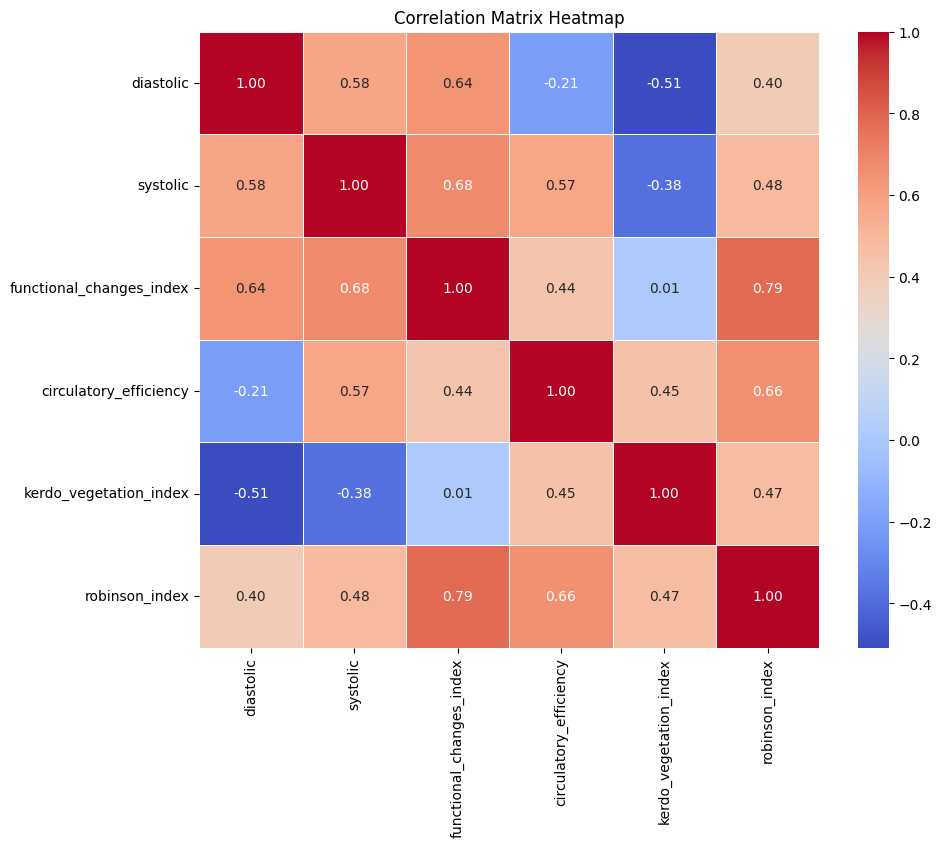

In [7]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = blood_pressure[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Interpretation

There is a strong correlation between FCI and robinson index, systolic, and diastolic. Also there is a strong correlation between robinson index and circulatory efficiency.

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


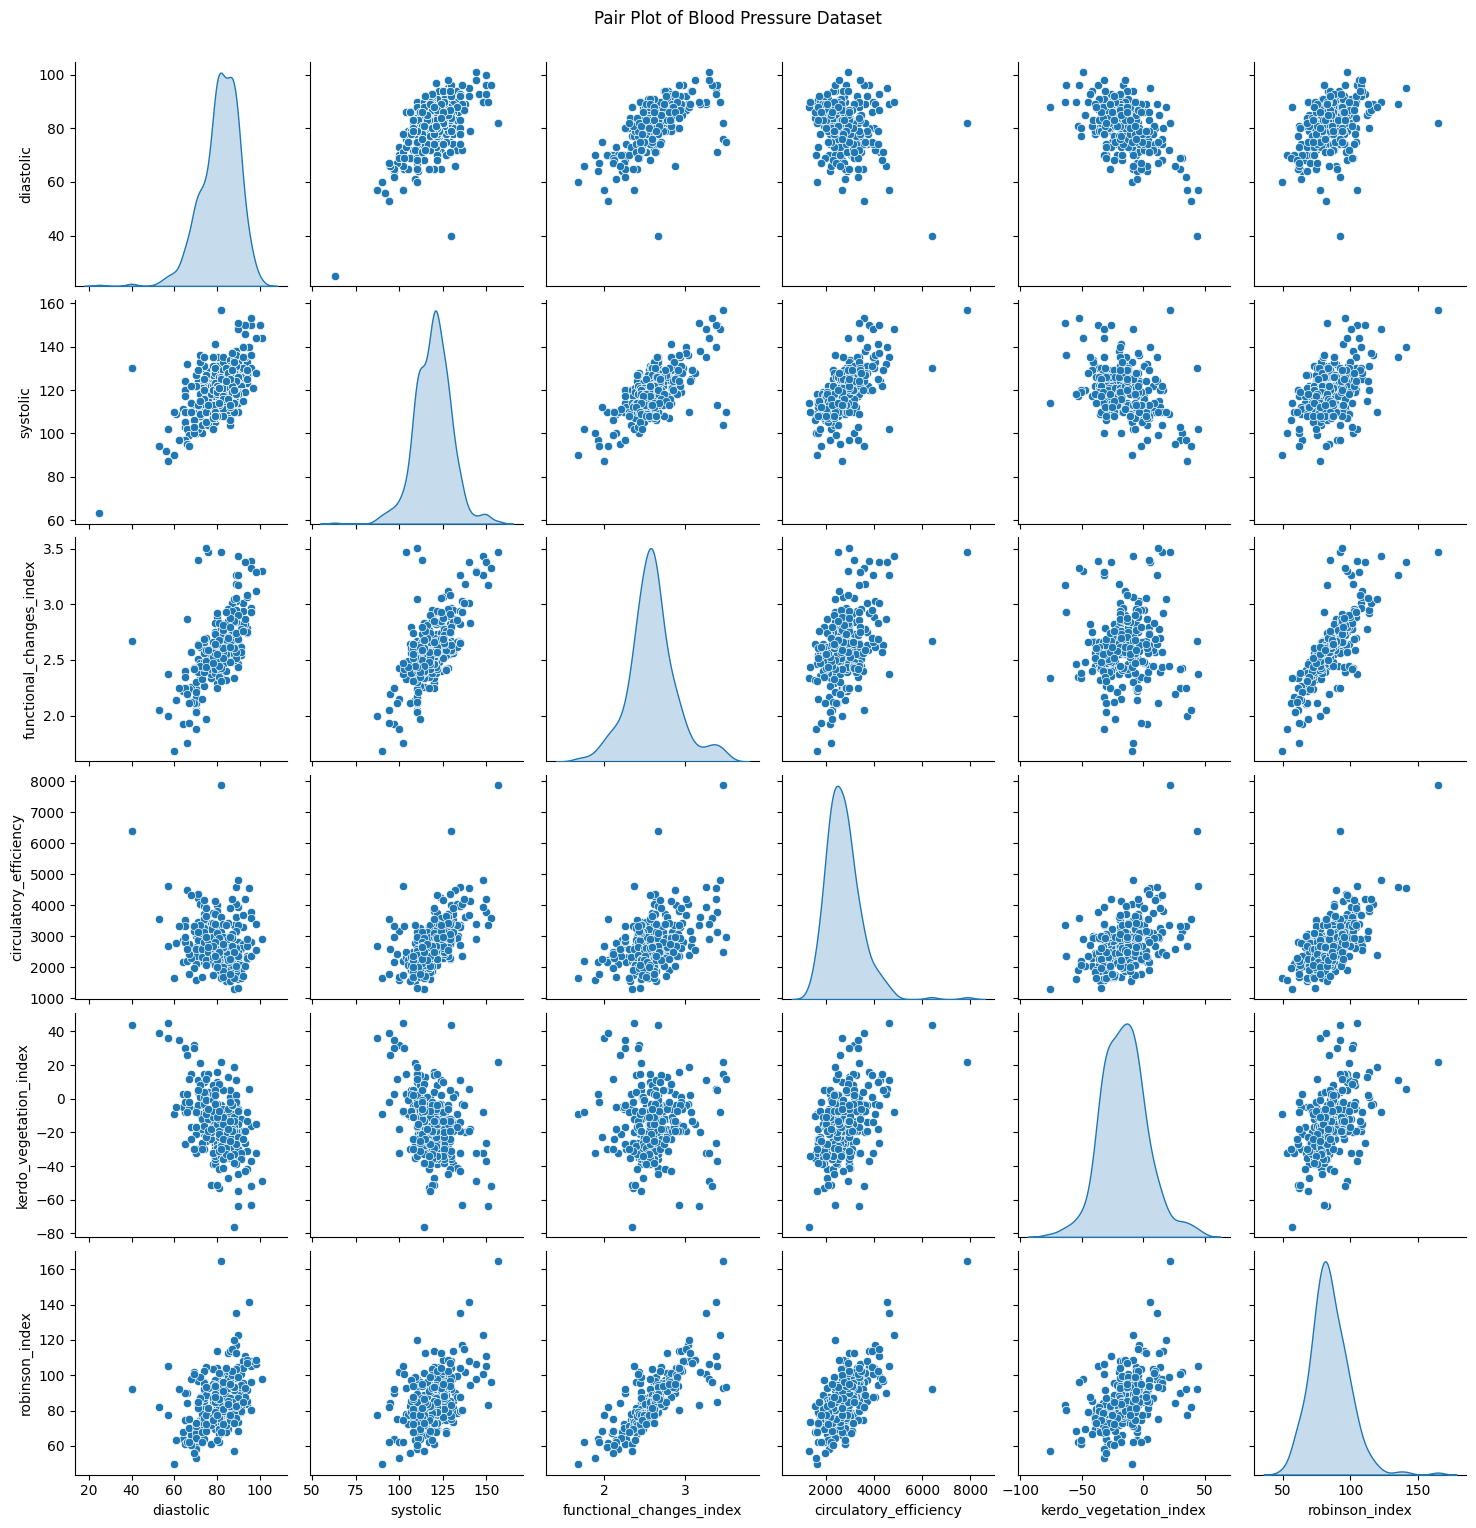

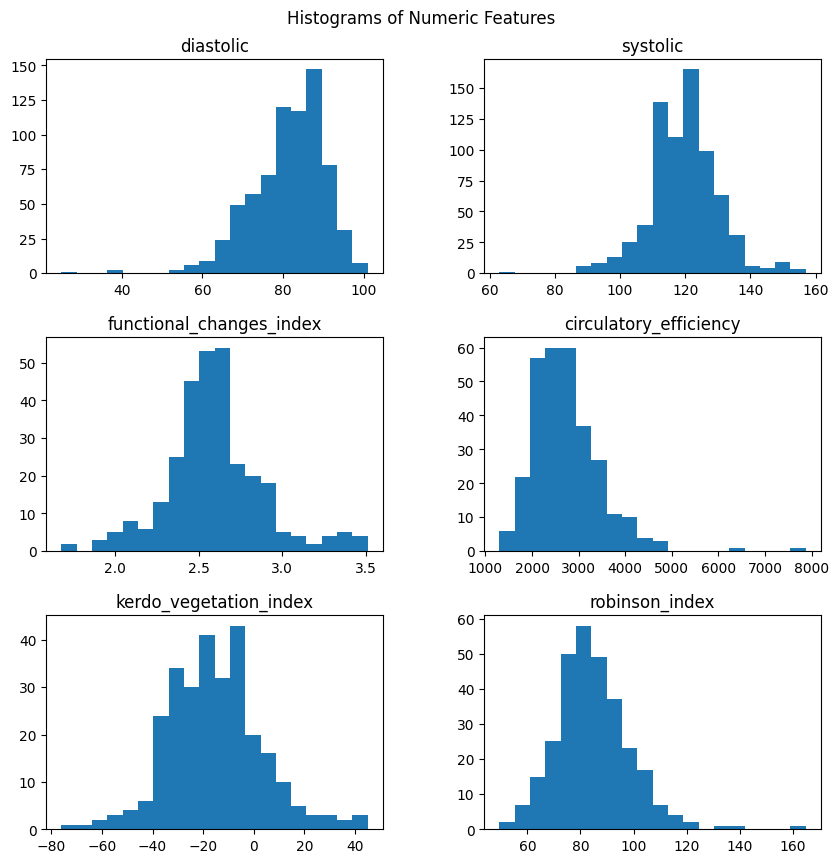

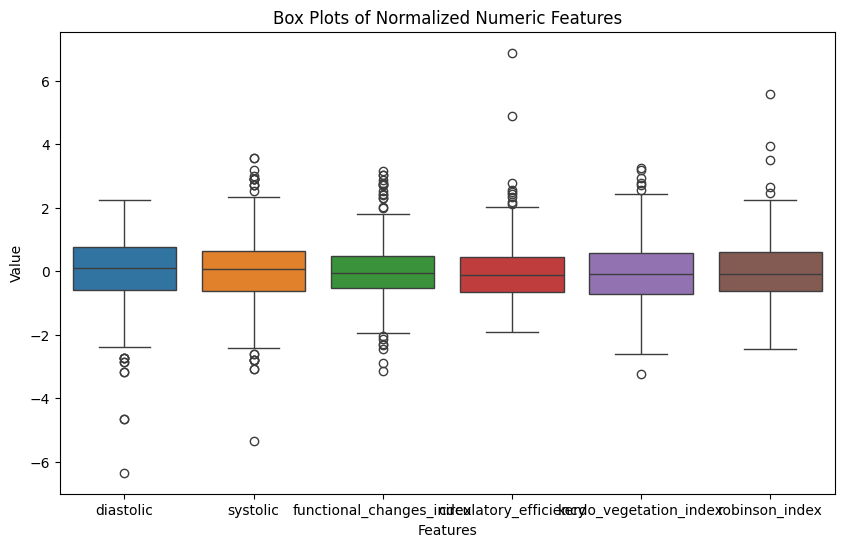

In [ ]:
# Data Visualization
sns.pairplot(blood_pressure[numeric_columns], diag_kind="kde")
plt.suptitle('Pair Plot of Blood Pressure Dataset', y=1.02)
plt.show()

# Visualize distributions
blood_pressure[numeric_columns].hist(bins=20, figsize=(10,10), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.93)
plt.show()

# Data transformation to make box plots more legible. 

"""
This transformation is being done because without normalization, the box plot provides useless visualization for all but one column.
The data is normalized using standard scalar.
"""

scaled_blood_pressure = pd.DataFrame(
    StandardScaler().fit_transform(blood_pressure[numeric_columns]),
    columns=numeric_columns
)

# Box plots to identify outlier
plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_blood_pressure[numeric_columns])
plt.title('Box Plots of Normalized Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.show()


## Interpretation

#### Pair Plot:

There are not clear collections of data for each category, or user_code. Data seems to be centered around a line that is easily given by an equation, but there are some outliers in the data. The outliers are not a big concern as the vast majority if data is around a clear line. All data may be clustered together as there are so many user codes which hides individual trends.

#### Histograms:

Histograms display the distribution of each numerical feature. Robinson index and circulatory efficiency are left skewed. Diastolic and systolic are right skewed. FCI and KVI follow a normal distribution.

#### Box Plots:

Box plots highlight the spread of the data and potential outliers. Outliers in systolic and diastolic blood pressures will be removed because these are likely issues in data collection. Circulatory efficieny has w outliers well outside of the normal range. This data will be filtered from the 1% to 99% to remove these outliers as the outliers are probobably data collection errors. Outliers in medical data can be useful to represent severe cases, but some of the values in there columns are likely not possible and represent issues in data collection.

## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?



Feature Engineering
-------------------
New Features: Index(['user_code', 'measurement_datetime', 'diastolic', 'systolic',
       'functional_changes_index', 'circulatory_efficiency',
       'kerdo_vegetation_index', 'robinson_index', 'pulse_pressure'],
      dtype='object')


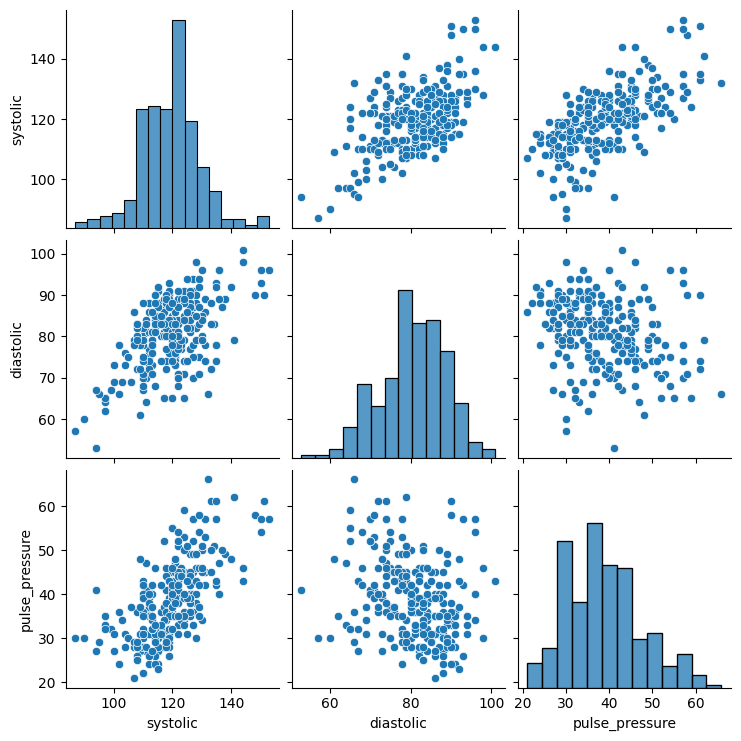

In [17]:
# Handling Outliers
"""
Systolic and Diastolic values well outside of normal ranges are removed.
Systolic and Diastolic need to be cvleaned of outliers since regular ranges are common knowledge and what is outside of this range is likely a data collection issue.
Circulatory efficiency is filtered from 1%-99% to remove the very large outliers that occured. The values well outside of the range lead to the belief that there has to be a collection error.

"""
blood_pressure = blood_pressure[
    (blood_pressure['systolic'].between(50, 250)) &
    (blood_pressure['diastolic'].between(30, 150))
]

lower = blood_pressure['circulatory_efficiency'].quantile(0.01)
upper = blood_pressure['circulatory_efficiency'].quantile(0.99)
blood_pressure = blood_pressure[
    blood_pressure['circulatory_efficiency'].between(lower, upper)
]

# Feature Engineering
print("\nFeature Engineering")
print("-------------------")
blood_pressure['pulse_pressure'] = blood_pressure['systolic'] - blood_pressure['diastolic']
print(f"New Features: {blood_pressure.columns}")

# Visualize new features
sns.pairplot(blood_pressure, vars=['systolic', 'diastolic', 'pulse_pressure'])
plt.show()

## Interpretation

#### New Features (Sepal Area and Petal Area):
The new pulse pressure feature is very relevant in health analysis. This provides more data to look at when analyzing the health of an individual and can provide deeper insight into blood pressure data.

The histograms show a clear linear shape for the majority of values except for a few outliers.

The bar chart shows a clear, symmetrical shape which represent clean data centered around a mean.

# Data Quality Assessment

#### Profiling:
The blood_pressure.csv data inlcludes columns: user_code, measurement_datetime, diastolic, systolic, function_changes_index, circulatory_efficiency, kerdo_vegetation_index, robinson_index. There are 720 rows of data. User_code is the categorical feature that reperesents the individual, measurement_datetime is the string that stores the datetime the data was collected, and diastolic, systolic, function_changes_index, circulatory_efficiency, kerdo_vegetation_index, and robinson_index are measured features of the individual. I added pulse_pressure which is systolic - diastolic blood pressure. This is an import measurement for assessing cardiovasuclar health.

#### Completeness:
Columnns user_code, measurement_datetime, diastolic, and systolic are complete for all rows. There are 422 vales missing for function_changes_index, 422 values missing for circulatory efficiency, 438 values missing for kerdo_vegetation_index, and 422 values missing for robinson_index. Since there are en equal number of missing values for function_changes_index, circulatory_index, and robinson_index, I believe these were collected together at set intervals at a frequency much less than diastolic and systolic blood pressure. Therefore, the missing values are likely a cause of experimental design and limitation. Function_changes_index, circulatory_efficiency, kerdo_vegetation_index, and robinson_index have rapid, large swings in values, so I do not beleive it is appropriate to estimate the >60% of values that are missing. Is these columns are important to a model, only complete data should be used.


#### Accuracy:
Data was collected by Bluetooth heartrate monitor, cellphone PPG (Photoplethysmography), user-connected gadgets, and clinically-validated assessments. Data shpws few egregious outliers and small standard deviaton relative tot range. This shows that the data is alligned between the measurement sources and most likely accurate. The three methods for data collection limit the possibility of a bad sensor corrupting the data as bad data should be easily identifiable. Systolic, diastolic, and circulatory efficiency outliers were handled as outliers were most egregious here.

#### Consistency
The small number of outliers and values for each column closely huddled around the mean show that the sensors must have been consistent and provided meaningful and consisitent data. Inconsistent data collection would be shown in outliers and data that is not centered around a clear mean. Expecially with health data, there is a known acceptible range and the vast majority of measurements should fal within this range, and for this dataset the profound majority of sample are not outliers and the outliers that exist were handled.

#### Integrity
This data has high integrity as clinically-validated procedures were taken to record this medical data. Also the bluetooth devices and gadgets are very accurate. FOr example the Apple Watch has an accuracy of >95%. The consisitency of the data also supports the integrity as many different data sources were used and there is no clear difference in measurements obtained by different data sources, as this would be seen in grouping of the data.

#### Distribution Measures
Systolic, functional_changes_index, kerdo_vegeation_iondex, and robinson_index are symmetrical as is shown by a near 0 skew. Diastolic has a left skew and circulatory_efficiency has a right skew. Systolic, funcitonal_changes_index, and kerdo_vegeation_index have a normal distrivution as is shown by a low kurtosis. Diastolic, circulatory_efficiency, and robinson index have heavy tails. Heavy tails show an increased number of outliers in the data, but circulatory efficiency is the only columns with very high kurtosis of >8. Therefore, I have handled the outliers in circulatory efficiency.

#### Lineage and Provenance
The data is well documented and collected by trusted methods and technology, so the data will remain relevant through time. The data related to Covid-19 which is nowhere near as prevelant as it was in 2020/2021, so this aspect of the data may age, but the data could still be used for modeling other illnesses that show similar symptoms.
